In [141]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [142]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [143]:
data=pd.read_csv('insurance.csv')

In [144]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [145]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [146]:
data=data.drop_duplicates()

In [147]:
data['smoker']=data['smoker'].map({'yes':1,'no':0})
data['sex']=data['sex'].map({'male':1,'female':0})

In [148]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [149]:
data['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [150]:
data['region']=data['region'].map({'southwest':0,'southeast':1,'northwest':2,'northeast':3})

In [151]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,0,16884.92400
1,18,1,33.770,1,0,1,1725.55230
2,28,1,33.000,3,0,1,4449.46200
3,33,1,22.705,0,0,2,21984.47061
4,32,1,28.880,0,0,2,3866.85520


In [152]:
X=data.drop('charges',axis=1)
y=data['charges']

In [153]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [154]:
X_scaled

array([[-1.44041773, -1.00977099, -0.45315959, -0.90923416,  1.96966039,
        -1.34316271],
       [-1.51164747,  0.99032355,  0.50942165, -0.07944162, -0.50770174,
        -0.43801727],
       [-0.79935006,  0.99032355,  0.3831546 ,  1.58014347, -0.50770174,
        -0.43801727],
       ...,
       [-1.51164747, -1.00977099,  1.01448983, -0.90923416, -0.50770174,
        -0.43801727],
       [-1.29795825, -1.00977099, -0.79752426, -0.90923416, -0.50770174,
        -1.34316271],
       [ 1.55123139, -1.00977099, -0.26129928, -0.90923416,  1.96966039,
         0.46712816]], shape=(1337, 6))

In [155]:
X_train,X_test,y_train,y_test=train_test_split(
    X_scaled,y,test_size=0.2,random_state=42)

In [156]:
model=LinearRegression()
model.fit(X_scaled,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [157]:
y_pred=model.predict(X_test)

In [158]:
print("Predicted values:",y_pred)

Predicted values: [ 8150.49520359  5014.94750485 14489.71030825 32371.86716422
  9050.31859882 13387.29190427 31077.19871324   867.06409885
 10872.74795509 11286.57902174 10538.37585919 33998.67145996
 31772.7639898  17450.12434339 10818.43586211  9074.30119582
  3595.6112107  32615.73270076  2524.46188962  5259.69912997
  3600.25010042 30937.37779254 15236.21261759 30738.42218261
 31958.51858732  5378.54157175 36486.64424277 37157.59837357
 11507.5713054  14168.70843312  6493.93189904 13019.38133556
   215.68797004 11797.25943651 40957.0131321  12097.42602286
  3919.47433669  3622.23260795 31753.29666368  9119.95606714
  7085.98968105 30691.8588783  35629.79707686 12398.12231836
  7258.71209942  2909.17684962  6215.15986021  8609.63887727
  4140.86826873  9095.74009386  6615.41897232 12276.94094057
 31950.89983886  3580.60581976 10664.12118341  9832.97314592
 10881.48585783  2231.78133422 32027.05075491  9382.11365886
 15791.31510334  8339.51051163 12719.90880069  1377.86664735
 16804

In [159]:
print("mean_squared_error:",mean_squared_error(y_test,y_pred))
print("r2_score:",r2_score(y_test,y_pred))

mean_squared_error: 34188376.88285949
r2_score: 0.813946946125202


In [169]:
person_data = pd.DataFrame([
    {'age': 30, 'sex':0, 'bmi':25, 'children':1, 'smoker':0,
     'region':0},
    {'age': 50, 'sex':1, 'bmi':28, 'children':2, 'smoker':1,
     'region':1}
])
predicted_charges = model.predict(person_data)
print("Predicted insurance charges for the individuals:", predicted_charges)

Predicted insurance charges for the individuals: [172888.75136141 261709.47734337]


c:\Users\sheri\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


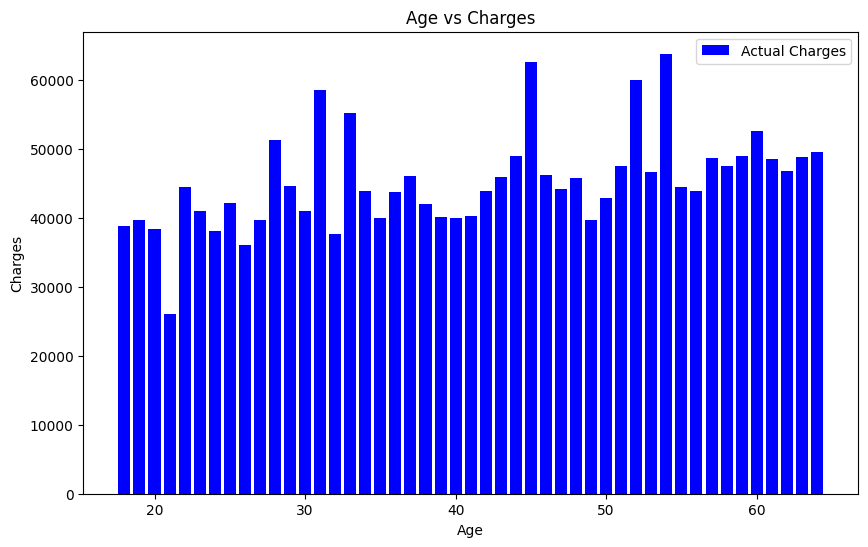

In [165]:
plt.figure(figsize=(10,6))
plt.bar(data['age'],data['charges'],color='blue',label='Actual Charges')
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Charges")
plt.legend()
plt.show()

In [171]:
coefficients = model.coef_
intercept = model.intercept_
feature_names = X.columns
print("Regression equation:")
equation = f"charges = {intercept:.2f}"
for coef, feature in zip(coefficients, feature_names):
    equation += f" + ({coef:.2f} * {feature})"
print(equation)


Regression equation:
charges = 13279.12 + (3610.90 * age) + (-64.70 * sex) + (2028.23 * bmi) + (576.98 * children) + (9614.72 * smoker) + (391.11 * region)
